# MACRO LANDSCAPE: World GDP, Inflation and Unemployment

In [87]:
#libraries 

import pandas as pd
import numpy as np
import datetime 

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [75]:
#Import csv data 
macro_data = pd.read_csv('macro_data.csv')

#Drop the Series Code and Country Code columns
macro_data = macro_data.drop(['Series Code', 'Country Code'], axis=1)

#Drop the not needed rows
macro_data = macro_data.drop([3, 4, 5, 6, 7])

#Rename the columns
macro_data['Series Name'] = macro_data['Series Name'].replace(
    {
        'GDP (current US$)': 'GDP',
        'Population, total': 'Population',
        'Inflation, consumer prices (annual %)': 'Inflation',
        'Unemployment, total (% of total labor force) (modeled ILO estimate)': 'Unemployment',      
    })

#Drop column of country name
macro_data = macro_data.drop(['Country Name'], axis=1)

#Drop NaN
macro_data = macro_data.dropna()

#View the data
macro_data.head()



,Series Name,1990 [YR1990],2000 [YR2000],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,GDP,22987402273855.3,3.385585e+13,7.547247e+13,7.670255e+13,8.171204e+13,8.688484e+13,8.814985e+13,8.576301e+13,9.784830e+13,1.017709e+14,1.061717e+14,..
1,Inflation,8.06346090938833,3.433516e+00,1.443857e+00,1.605539e+00,2.254277e+00,2.442583e+00,2.206073e+00,1.905664e+00,3.475403e+00,7.930929e+00,5.733163e+00,..
2,Unemployment,..,6.123041e+00,6.006559e+00,5.978274e+00,5.907231e+00,5.768983e+00,5.598931e+00,6.608805e+00,6.064446e+00,5.260711e+00,4.916572e+00,4.89214997028311


In [76]:
#create a backup of the data
macro_data_backup = macro_data.copy()

#Transpose the data
macro_data = macro_data.T

In [77]:
#Rename columns using the first row
macro_data.columns = macro_data.iloc[0]

#Drop the first row (Series Name)
macro_data = macro_data.drop(macro_data.index[0])

#View the data
macro_data.head()


Series Name,GDP,Inflation,Unemployment
1990 [YR1990],22987402273855.3,8.06346090938833,..
2000 [YR2000],33855853033266.601562,3.433516,6.123041
2015 [YR2015],75472473882835.09375,1.443857,6.006559
2016 [YR2016],76702553625899.09375,1.605539,5.978274
2017 [YR2017],81712043350515.5,2.254277,5.907231


In [78]:
#Clean up the year format and convert to datetime index
macro_data.index = macro_data.index.str.replace(' \[YR\d{4}\]', '', regex=True).astype(int)
macro_data.index = pd.to_datetime(macro_data.index, format='%Y')

#Sort the index
macro_data = macro_data.sort_index()

#View the data
macro_data.dropna(inplace=True)

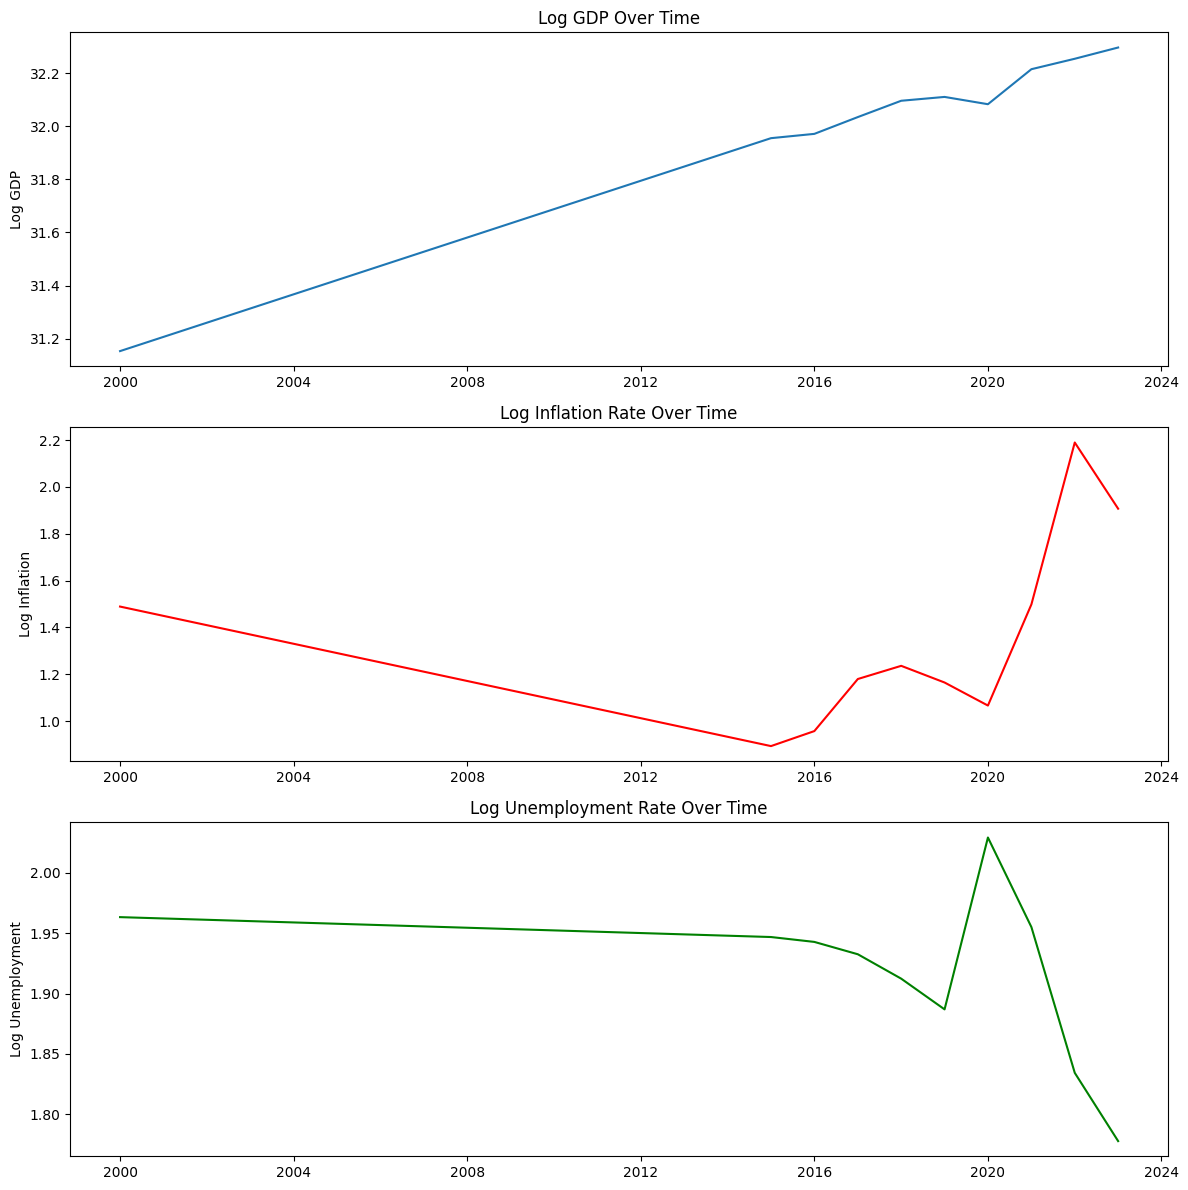

Log-transformed Data:
Series Name        GDP  Inflation  Unemployment
2000-01-01   31.153133   1.489193      1.963335
2015-01-01   31.954789   0.893578      1.946847
2016-01-01   31.970956   0.957640      1.942802
2017-01-01   32.034223   1.179970      1.932569
2018-01-01   32.095605   1.236222      1.912351
2019-01-01   32.110059   1.165047      1.886908
2020-01-01   32.082609   1.066662      2.029306
2021-01-01   32.214439   1.498596      1.955075
2022-01-01   32.253745   2.189520      1.834294
2023-01-01   32.296078   1.907045      1.777757


In [85]:
#Create a copy of the data to work with
macro_data_log = macro_data.copy()

#Take natural log of GDP (since it's in absolute values)
macro_data_log['GDP'] = np.log(macro_data_log['GDP'])

#For inflation and unemployment, we can take log(1 + x) since they're already in percentages
#This preserves the original scale while making the distribution more normal
macro_data_log['Inflation'] = np.log1p(macro_data_log['Inflation'])
macro_data_log['Unemployment'] = np.log1p(macro_data_log['Unemployment'])

#Create subplots to visualize the log-transformed data
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

#Plot log GDP
ax1.plot(macro_data_log.index, macro_data_log['GDP'])
ax1.set_title('Log GDP Over Time')
ax1.set_ylabel('Log GDP')

#Plot log Inflation
ax2.plot(macro_data_log.index, macro_data_log['Inflation'], color='red')
ax2.set_title('Log Inflation Rate Over Time')
ax2.set_ylabel('Log Inflation')

#Plot log Unemployment
ax3.plot(macro_data_log.index, macro_data_log['Unemployment'], color='green')
ax3.set_title('Log Unemployment Rate Over Time')
ax3.set_ylabel('Log Unemployment')

plt.tight_layout()
plt.show()

#Print the transformed data
print("Log-transformed Data:")
print(macro_data_log)

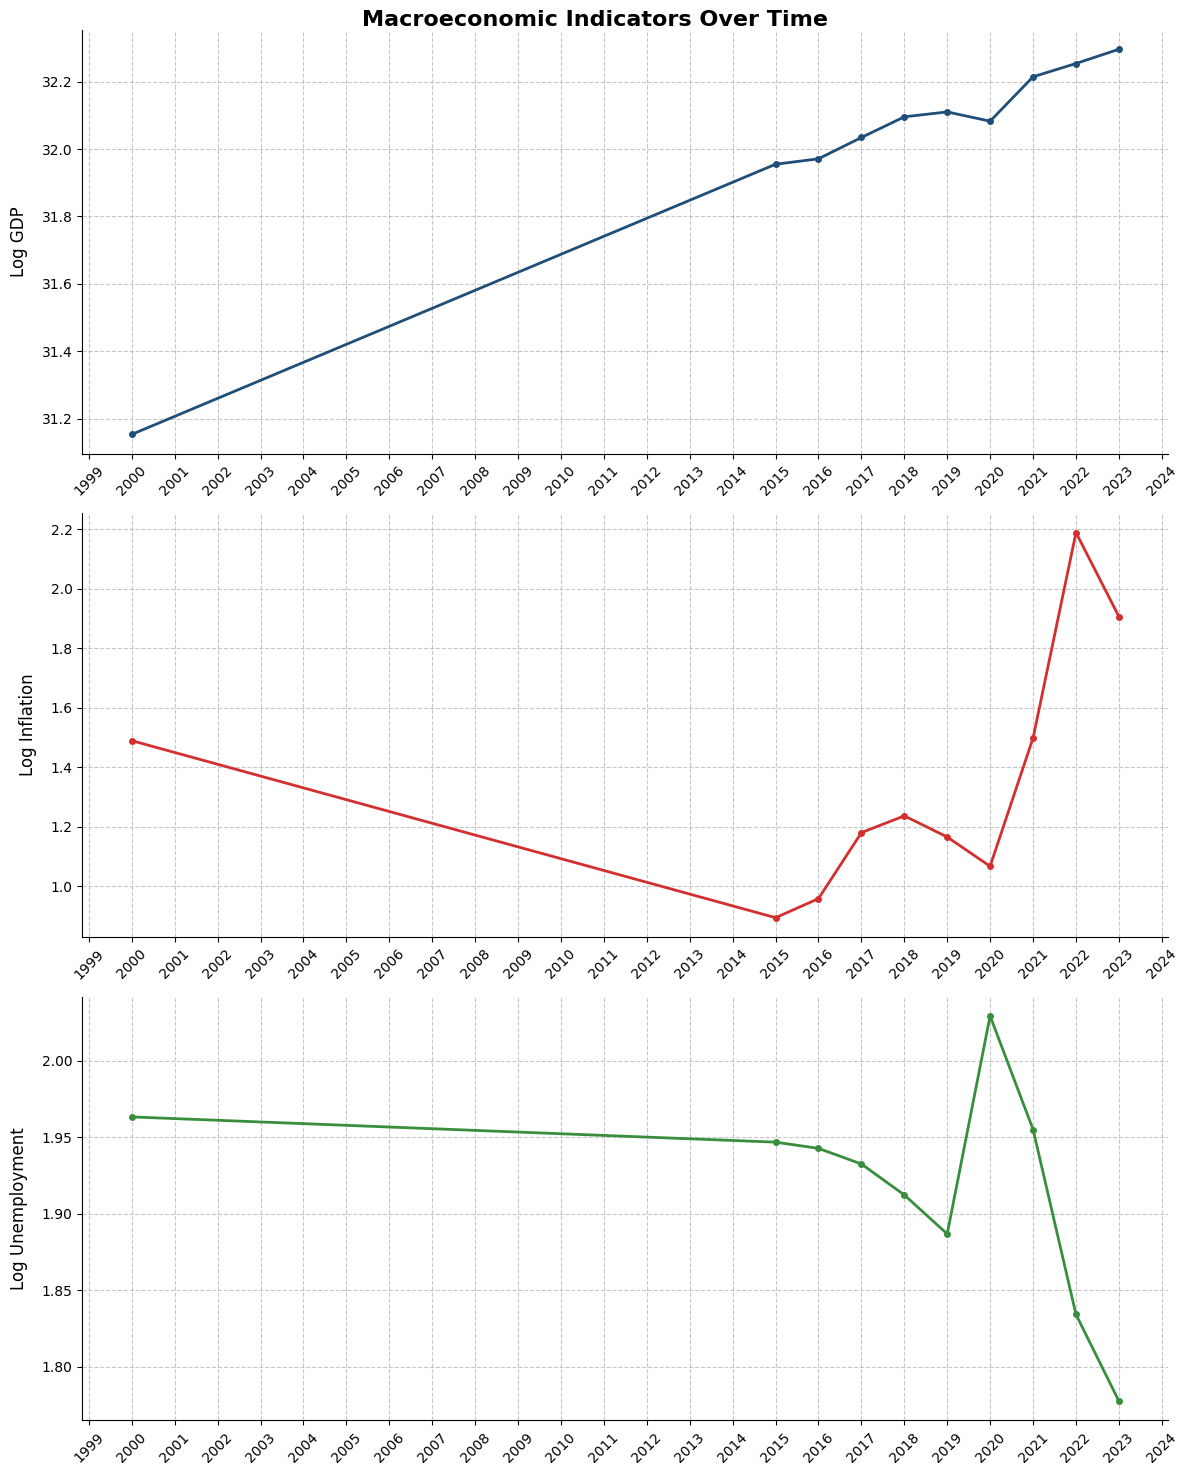

<Figure size 640x480 with 0 Axes>

In [91]:
#Create a Better visualization last one is very bad

#Set the style
plt.style.use('default')

#Define McKinsey color palette
mckinsey_colors = {
    'blue': '#1F4E79',
    'light_blue': '#4B8BBE',
    'red': '#D32F2F',
    'green': '#388E3C',
    'gray': '#757575'
}

#Create figure with subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

#Add the main title at the top
fig.suptitle('Macroeconomic Indicators Over Time', 
             fontsize=16, 
             fontweight='bold',
             y=0.98)  # Position it very close to the top

#Plot log GDP
ax1.plot(macro_data_log.index, macro_data_log['GDP'], 
         color=mckinsey_colors['blue'], 
         linewidth=2,
         marker='o',
         markersize=4)
ax1.set_ylabel('Log GDP', 
               fontsize=12,
               labelpad=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#Plot log Inflation
ax2.plot(macro_data_log.index, macro_data_log['Inflation'], 
         color=mckinsey_colors['red'], 
         linewidth=2,
         marker='o',
         markersize=4)
ax2.set_ylabel('Log Inflation', 
               fontsize=12,
               labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

#Plot log Unemployment
ax3.plot(macro_data_log.index, macro_data_log['Unemployment'], 
         color=mckinsey_colors['green'], 
         linewidth=2,
         marker='o',
         markersize=4)
ax3.set_ylabel('Log Unemployment', 
               fontsize=12,
               labelpad=10)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

#Format x-axis dates
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

#Adjust layout
plt.tight_layout()

#Show the plot
plt.show()

#Save the figure with high DPI for better quality
plt.savefig('macro_indicators.png', dpi=300, bbox_inches='tight')

## GDP for the USA only 

In [120]:
#Load the csv file we got from WordlBank
usa_gpd = pd.read_csv('usa.csv')

#Drop uneccesary columns
usa_gpd = usa_gpd.drop(['Series Code', 'Country Code'], axis=1)

#Drop uneccesary rows
usa_gpd = usa_gpd.drop([1, 2, 3, 4])

#Rename variables
usa_gpd['Series Name'] = usa_gpd['Series Name'].replace(
    {
        'GDP (current US$)': 'GDP',      
    })

#Drop country name 
usa_gpd = usa_gpd.drop(['Country Name'], axis=1)

#Drop NaN
usa_gpd = usa_gpd.dropna()

#View the data
usa_gpd.head()

,Series Name,1990 [YR1990],2000 [YR2000],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,GDP,5.963144e+12,1.025095e+13,1.829502e+13,1.880491e+13,1.961210e+13,2.065652e+13,2.153998e+13,2.135410e+13,2.368117e+13,2.600689e+13,2.772071e+13,..


In [121]:
#Transpose data
usa_gpd = usa_gpd.T

#Fix the index
usa_gpd.columns = usa_gpd.iloc[0]

#Set the index 
usa_gpd = usa_gpd.drop(usa_gpd.index[0])

#Format the year column
usa_gpd.index = usa_gpd.index.str.replace(' \[YR\d{4}\]', '', regex=True).astype(int)

#Set the index to pd datetime 
usa_gpd.index = pd.to_datetime(usa_gpd.index, format='%Y')

#Sort by index (by time)
usa_gpd = usa_gpd.sort_index()

#View the data 
usa_gpd.head()

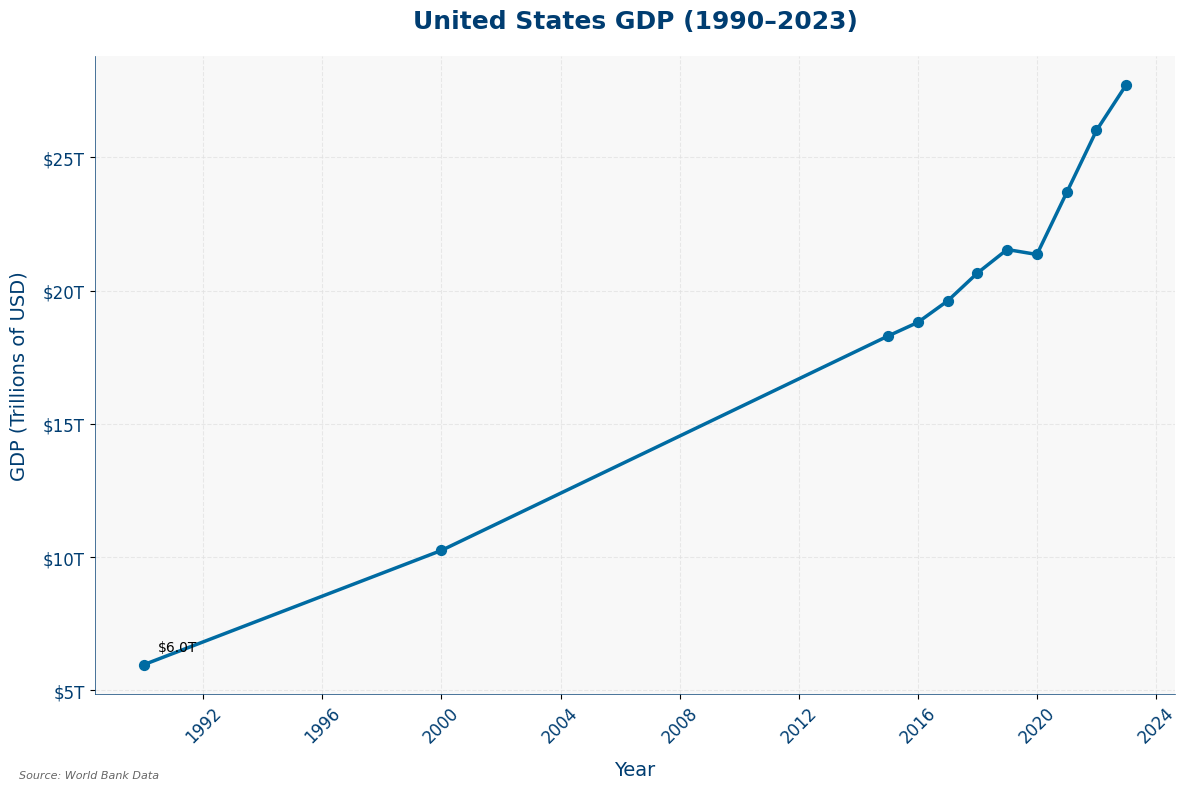

In [132]:

# --- Ensure GDP is numeric ---
usa_gpd['GDP'] = pd.to_numeric(usa_gpd['GDP'], errors='coerce')

# --- Set McKinsey-style aesthetics ---
sns.set_theme(style="whitegrid", font='Arial')
plt.style.use('default')

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the GDP line (in trillions)
ax.plot(usa_gpd.index, usa_gpd['GDP'] / 1e12, linewidth=2.5, color='#006BA2')

# Scatter data points
ax.scatter(usa_gpd.index, usa_gpd['GDP'] / 1e12, color='#006BA2', s=50, zorder=5)

# Customize grid and background
ax.grid(True, linestyle='--', alpha=0.7, color='#E0E0E0')
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')

# Format y-axis as trillions of USD
def trillions_formatter(x, pos):
    return f'${x:,.0f}T'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(trillions_formatter))

# Title and labels
plt.title('United States GDP (1990–2023)', fontsize=18, fontweight='bold', pad=20, color='#003D71')
plt.xlabel('Year', fontsize=14, labelpad=10, color='#003D71')
plt.ylabel('GDP (Trillions of USD)', fontsize=14, labelpad=10, color='#003D71')

# Remove top/right spines, style others
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('#003D71')
ax.spines['bottom'].set_color('#003D71')

# Customize tick appearance
plt.xticks(rotation=45, fontsize=12, color='#003D71')
plt.yticks(fontsize=12, color='#003D71')

# Annotate first and last values
first_year = usa_gpd.index[0]
last_year = usa_gpd.index[-1]
first_value = usa_gpd['GDP'].iloc[0] / 1e12
last_value = usa_gpd['GDP'].iloc[-1] / 1e12

ax.annotate(f'${first_value:.1f}T', 
            xy=(first_year, first_value),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=10)

ax.annotate(f'${last_value:.1f}T', 
            xy=(last_year, last_value),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=10)

# Add a source note
plt.figtext(0.02, 0.02, 'Source: World Bank Data', 
            fontsize=8, style='italic', color='#666666')

# Adjust layout and save
plt.tight_layout()
plt.savefig('us_gdp_mckinsey.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
